##### Imports

In [1]:
from typing import Dict
import json
import csv

##### Chargement des fichiers

In [2]:
path_sol_climat = "RPG2023_sol_climat"
path_parcelles_graphiques = "PARCELLES_GRAPHIQUES"

In [3]:
import pandas as pd

df = pd.read_csv("data/" + path_sol_climat + ".csv")

C:\Users\GALLIOT\AppData\Local\Temp\ipykernel_2960\3327928740.py:3: DtypeWarning: Columns (1,3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/" + path_sol_climat + ".csv")


In [4]:
import geopandas as gpd

gdf = gpd.read_file("data/" + path_parcelles_graphiques + ".gpkg")

In [5]:
gdf.head(5)

,ID_PARCEL,SURF_PARC,CODE_CULTU,CODE_GROUP,CULTURE_D1,CULTURE_D2,geometry
0,1,5.01,ORH,3,,,"POLYGON ((620859.121 7049174.538, 621155.742 7..."
1,2,0.43,TRN,6,,,"POLYGON ((518271.056 6380847.362, 518271.088 6..."
2,3,2.34,BTH,1,,,"POLYGON ((653603.846 6971494.032, 653548.732 6..."
3,4,2.31,VRC,21,,,"POLYGON ((450066.555 6519505.157, 449911.365 6..."
4,5,0.14,SNE,28,,,"POLYGON ((542585.535 6905398.389, 542579.8 690..."


In [6]:
print(df.shape)
print(gdf.shape)

(9797405, 27)
(9797405, 7)


#### Filtrage des parcelles intéressantes

In [7]:
VALID_CODES = {"PPH", "SPH", "SPL", "CAE", "CEE"}

gdf_filt = gdf[gdf["CODE_CULTU"].isin(VALID_CODES)]

In [8]:
print(gdf_filt.shape)

(3382534, 7)


In [9]:
df["id_parcel"] = df["id_parcel"].astype(str)
gdf_filt["ID_PARCEL"] = gdf_filt["ID_PARCEL"].astype(str)

c:\Users\GALLIOT\AppData\Local\Programs\Python\Python313\Lib\site-packages\geopandas\geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [10]:
final_df = df.merge(
    gdf_filt,
    left_on="id_parcel",
    right_on="ID_PARCEL",
    how="inner"
)

In [11]:
print(final_df.shape)
print(final_df.head(5))

(3382534, 34)
  id_parcel com_parc  pct_com dep_parc  reg_parc  alt_mean  alt_min  alt_max  \
0   1182569     1001    100.0        1      84.0     270.0    268.0    271.0   
1    128213     1001    100.0        1      84.0     228.0    213.0    243.0   
2   1313207     1001    100.0        1      84.0     209.0    209.0    209.0   
3   1464937     1001    100.0        1      84.0     247.0    238.0    255.0   
4   1577124     1001    100.0        1      84.0     219.0    214.0    234.0   

   pente_mean  expo_mean  ... smu_4  part_smu_4  stu_dom_4 ID_PARCEL  \
0        2.05     225.39  ...   NaN         0.0        NaN   1182569   
1        6.40     190.21  ...   NaN         0.0        NaN    128213   
2        0.43      96.14  ...   NaN         0.0        NaN   1313207   
3        2.75     142.18  ...   NaN         0.0        NaN   1464937   
4        2.51     198.17  ...   NaN         0.0        NaN   1577124   

   SURF_PARC  CODE_CULTU  CODE_GROUP  CULTURE_D1  CULTURE_D2  \
0       

In [12]:
COLUMNS_TO_KEEP = [
    "id_parcel", "dep_parc", "com_parc", "alt_mean", "alt_min", "alt_max",
    "pente_mean", "expo_mean", "mf_lambx", "mf_lamby", "mf_maille",
    "SURF_PARC", "CODE_CULTU", "geometry", "reg_parc"
]

final_df = final_df[COLUMNS_TO_KEEP]

In [13]:
print(final_df.shape)

(3382534, 15)


In [14]:
VALID_DPT = {74} # {1, 7, 26, 38, 42, 69, 73, 74}
# filtered_final_df = final_df[final_df["dep_parc"].isin(VALID_DPT)]
filtered_final_df = final_df

In [ ]:
print(filtered_final_df.shape)

(3382534, 15)
<class 'shapely.geometry.polygon.Polygon'>


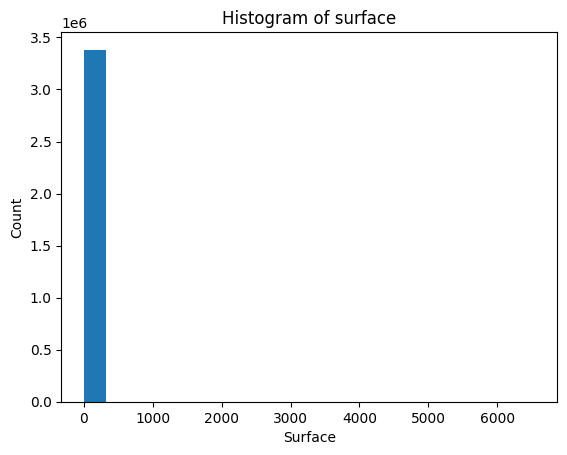

In [16]:
import matplotlib.pyplot as plt

plt.hist(filtered_final_df["SURF_PARC"].dropna(), bins=20)
plt.xlabel("Surface")
plt.ylabel("Count")
plt.title("Histogram of surface")
plt.show()


In [17]:
triees_par_tailles = filtered_final_df["SURF_PARC"].loc[filtered_final_df["SURF_PARC"] > 2].sort_values(ascending=False)

print(
    triees_par_tailles
)

2645425    6545.040039
2668802    5964.149902
1177050    3888.199951
2645527    2969.909912
1169047    2819.850098
              ...     
1734210       2.010000
3075972       2.010000
423242        2.010000
2088511       2.010000
2419516       2.010000
Name: SURF_PARC, Length: 1177003, dtype: float32


In [119]:
NUMBER_TO_SELECT = 100000

prairies_selectionnees = (
    filtered_final_df
    .sort_values(by="SURF_PARC", ascending=False)
    .head(NUMBER_TO_SELECT)
)

In [120]:
# print(prairies_selectionnees.head(3))
print(prairies_selectionnees.shape)

(100000, 15)


#### Suppression de coordonnées

In [122]:
type(prairies_selectionnees['geometry'].iloc[0])

shapely.geometry.polygon.Polygon

In [123]:
from shapely.geometry import Polygon, MultiPolygon

# Création du GeoDataFrame
gdf = gpd.GeoDataFrame(prairies_selectionnees, geometry='geometry')

In [126]:
from shapely.geometry import Polygon, MultiPolygon, LinearRing
import numpy as np

def resample_polygon(geom, max_points=20):
    if geom.is_empty:
        return geom

    if isinstance(geom, MultiPolygon):
        # Resample each polygon in the multipolygon
        return MultiPolygon([resample_polygon(p, max_points) for p in geom.geoms])
    
    coords = np.array(geom.exterior.coords)
    n = len(coords)
    
    if n <= max_points:
        return geom  # already small enough

    # Select max_points evenly spaced indices
    indices = np.linspace(0, n-1, max_points, dtype=int)
    new_coords = coords[indices]
    
    # Ensure the polygon is closed
    if not np.array_equal(new_coords[0], new_coords[-1]):
        new_coords = np.vstack([new_coords, new_coords[0]])
    
    return Polygon(new_coords)


In [ ]:
gdf['geometry_simplified'] = gdf['geometry'].apply(lambda g: resample_polygon(g, max_points=20))

In [129]:
gdf = gdf.drop(columns='geometry').rename(columns={'geometry_simplified': 'geometry'})

#### Test sur un dpt

In [96]:
# pour un dpt
LYON = {69}
lyon_prairies = prairies_selectionnees[prairies_selectionnees["dep_parc"].isin(LYON)]

#### Transformation en dict

In [131]:
final_dict = (
  gdf.set_index("id_parcel")
    .to_dict(orient="index")
)

In [97]:
lyon_dict = (
    lyon_prairies.set_index("id_parcel")
      .to_dict(orient="index")
)

#### Création csv

In [98]:
def write_csv_from_dict(
    data: Dict,
    file_path: str,
    key_name: str = "id"
):
    if not data:
        raise ValueError("Input dict is empty")

    fieldnames = [key_name] + list(next(iter(data.values())).keys())

    with open(file_path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()

        for key, row in data.items():
            writer.writerow({key_name: key, **row})

In [132]:
write_csv_from_dict(
    final_dict,
    "extracted_data/" + "parcelles.csv",
    key_name="id_parcel"
)

In [99]:
write_csv_from_dict(
    lyon_dict,
    "extracted_data/" + "rhoneTest.csv",
    key_name="id_parcel"
)